# 04 — Customer Analysis
تحليل قاعدة العملاء، النشاط، القيمة، والعملاء ذوي المساهمة المرتفعة.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = Path('../data/processed')
OUT = Path('../visualizations/customer')
OUT.mkdir(parents=True, exist_ok=True)
source = PROCESSED / 'final_dataset.csv'
if not source.exists():
    source = PROCESSED / 'cleaned_transactions.csv'
if not source.exists():
    raise FileNotFoundError('Run the cleaning notebook and create processed data first.')
df = pd.read_csv(source)

def find_column(candidates, required=True):
    column = next((c for c in candidates if c in df.columns), None)
    if required and column is None:
        raise KeyError(f'Expected one of {candidates}; available columns: {list(df.columns)}')
    return column

customer_col = find_column(['customer_id', 'customerId', 'client_id'])
amount_col = find_column(['amount_usd', 'amount', 'transaction_amount', 'value'])
transaction_col = find_column(['transaction_id', 'transactionId', 'id'], required=False)
status_col = find_column(['transaction_status', 'status'], required=False)
date_col = find_column(['transaction_date', 'date', 'created_at'], required=False)
if status_col:
    completed = df[df[status_col].astype(str).str.lower().isin(['completed', 'complete', 'success', 'successful'])].copy()
    if completed.empty:
        completed = df.copy()
else:
    completed = df.copy()
print(f'Using customer={customer_col}, amount={amount_col}, rows={len(completed)}')

C:\Users\user\AppData\Local\Temp\ipykernel_3324\3669636480.py:13: DtypeWarning: Columns (13,36,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(source)


Using customer=customer_id, amount=amount_usd, rows=476202


In [2]:
aggregations = {
    'transaction_count': (customer_col, 'size'),
    'total_transaction_value': (amount_col, 'sum'),
    'average_transaction_value': (amount_col, 'mean'),
}
if transaction_col:
    aggregations['unique_transactions'] = (transaction_col, 'nunique')
customer_summary = completed.groupby(customer_col).agg(**aggregations).reset_index()
customer_summary['value_rank'] = customer_summary['total_transaction_value'].rank(method='dense', ascending=False).astype(int)
customer_summary.to_csv(PROCESSED / 'customer_summary.csv', index=False)
customer_summary.sort_values('total_transaction_value', ascending=False).head(10)

,customer_id,transaction_count,total_transaction_value,average_transaction_value,unique_transactions,value_rank
124,C0000125,6031,1671886.86,277.215530,6031,1
54,C0000055,5849,1657876.14,283.446083,5849,2
90,C0000091,4755,1229621.38,258.595453,4755,3
141,C0000142,4658,1157778.54,248.557007,4658,4
49,C0000050,4813,1101128.94,228.782244,4813,5
83,C0000084,4823,1079453.71,223.813749,4823,6
151,C0000152,5602,1036681.36,185.055580,5602,7
96,C0000097,5185,1022893.32,197.279329,5185,8
138,C0000139,5933,1020638.62,172.027409,5933,9
21,C0000022,4723,991106.84,209.846885,4723,10


In [3]:
kpis = pd.DataFrame([{
    'customers_in_data': df[customer_col].nunique(dropna=True),
    'active_customers': completed[customer_col].nunique(dropna=True),
    'inactive_customers': df[customer_col].nunique(dropna=True) - completed[customer_col].nunique(dropna=True),
    'average_customer_value': customer_summary['total_transaction_value'].mean(),
    'median_customer_value': customer_summary['total_transaction_value'].median(),
}])
kpis.to_csv(PROCESSED / 'customer_kpis.csv', index=False)
kpis.T.rename(columns={0: 'value'})

,value
customers_in_data,200.00000
active_customers,200.00000
inactive_customers,0.00000
average_customer_value,378391.87925
median_customer_value,285491.59500


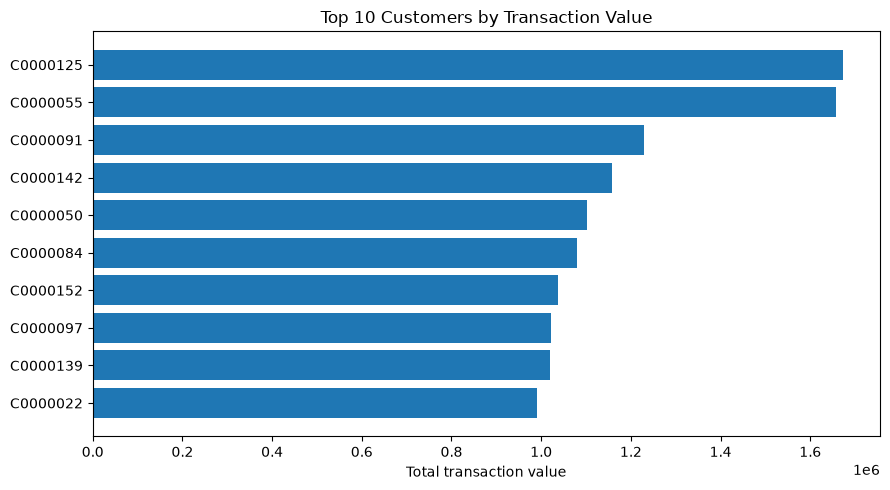

In [4]:
top = customer_summary.nlargest(10, 'total_transaction_value').sort_values('total_transaction_value')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top[customer_col].astype(str), top['total_transaction_value'])
ax.set_title('Top 10 Customers by Transaction Value')
ax.set_xlabel('Total transaction value')
fig.tight_layout()
fig.savefig(OUT / 'top_customers_by_value.png', dpi=150)
plt.show()
plt.close(fig)

## Business questions
- هل العملاء الأعلى قيمة هم نفسهم الأكثر تكرارًا؟
- ما نسبة قيمة المعاملات التي يساهم بها أعلى 10% من العملاء؟
- هل توجد فجوة كبيرة بين المتوسط والوسيط؟
- لا تُعرّف high-value threshold قبل فحص توزيع البيانات وتوثيق القاعدة.